In [160]:
%load_ext autoreload
%autoreload 2

import numpy as np
import numpy.linalg as LA
import scipy.constants as const
from scipy.spatial.transform import Rotation

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

%matplotlib ipympl


import sys
sys.path.append('../src')
import satellites as sat
import stateest as se

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
import matplotlib as mpl

mpl.rcParams.update({
    # figure
    'figure.figsize':       [8, 6],
    'figure.dpi':           150,
    'figure.facecolor':     'white',

    # axes
    'axes.titlesize':       14,
    'axes.labelsize':       12,
    'axes.linewidth':       1.0,
    'axes.grid':            True,
    'axes.spines.top':      True,
    'axes.spines.right':    True,

    # grid
    'grid.linestyle':       '-',
    'grid.linewidth':       0.5,
    'grid.alpha':           0.75,

    # lines
    'lines.linewidth':      1.5,
    'lines.markersize':     6,

    # ticks
    'xtick.labelsize':      10,
    'ytick.labelsize':      10,
    'xtick.direction':      'in',
    'ytick.direction':      'in',

    # legend
    'legend.fontsize':      10,
    'legend.frameon':       True,
    'legend.framealpha':    0.8,

    # font
    'font.family':          'sans-serif',
    'font.size':            11,

    # saving
    'savefig.dpi':          300,
    'savefig.bbox':         'tight',
    'savefig.facecolor':    'white',
})

# Orbit Simulation

In [279]:
SIM_TIME_DELTA_S = 7.11

XHAT  = np.reshape( [1,0,0], [1,3])
YHAT  = np.reshape( [0,1,0], [1,3])
ZHAT  = np.reshape( [0,0,1], [1,3])

dist1 = sat.EARTH_RADIUS_M + 1000
vel1 = 7904.76692
mass1 = 100

nobjects = 25
rng = np.random.default_rng( seed = 123 )

# rdilate = 1.23 # no variation in radius
phi = 0 # no variation in longitude
# rdilate = rng.uniform(1, 1.13, [nobjects,1])
rdilate = np.linspace(1,1.13, nobjects).reshape([nobjects,1])
# phi = const.pi * rng.uniform(0, 2, [nobjects,1])
theta = 1.0*const.pi/2 * np.ones([nobjects, 1])
# theta = const.pi * rng.uniform(0.25, 0.5, [nobjects,1])
# velang = np.deg2rad( rng.uniform( 0, 3, [nobjects,1] ))
velang = np.deg2rad([0]*nobjects)

rvec = rdilate * (
    np.cos(phi)*np.sin(theta)*XHAT
    + np.sin(phi)*np.sin(theta)*YHAT
    + np.cos(theta)*ZHAT
    )
thvec = (
    -np.sin(phi)*np.sin(theta)*XHAT
    + np.cos(phi)*np.sin(theta)*YHAT
    + np.cos(theta)*ZHAT
    )

orbit_objects = []
for r,th,va in zip(rvec, thvec, velang):
    rot = Rotation.from_rotvec( va * ZHAT )
    orbit_objects.append(
        sat.GravityObject( 
            xyz_m = dist1 * r,
            vxyz_mps = rot.as_matrix() @ (vel1*th),
            mass_kg=mass1
        )
    )

esys = sat.EarthSystem( j2_correction=True, delta_time_s=SIM_TIME_DELTA_S )
for s in orbit_objects:
    esys.add_object( s )

esys.init_snapshots( n_time_steps=2 )


N_TIME_STEPS = 100
for i in range(N_TIME_STEPS):
    esys.propagate_step()
    
r = np.stack(esys.positions)
v = np.stack(esys.velocities)
a = np.stack(esys.accels)


In [290]:
esys.objects[0].position


array([[6.37913700e+06, 0.00000000e+00, 3.90609485e-10]])

## plots

/tmp/ipykernel_49749/3628100026.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x,y,z,c=color_fun(rdilate[i]), **ls)


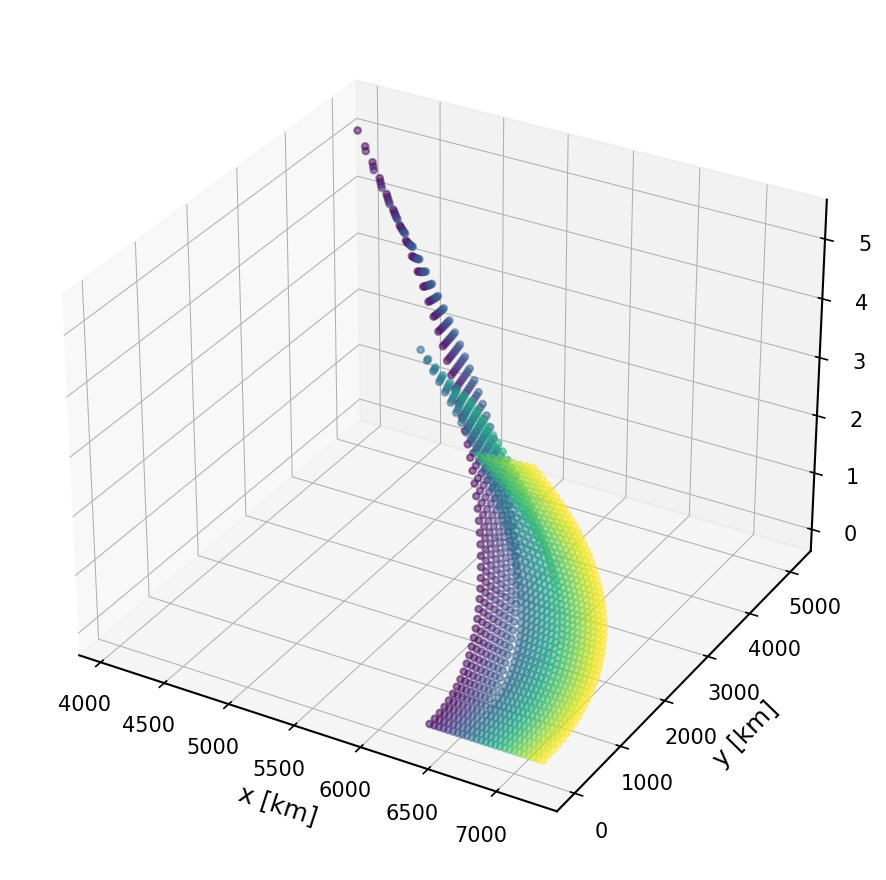

In [282]:
ls = {
    'cmap': 'viridis',
    's': 10,           # marker size
    'alpha': 0.5,      # transparency
    'depthshade': True, # shade markers by depth
    
}

timevec = esys.delta_time_s * np.arange(N_TIME_STEPS+2)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
npts_step = 2
cmap = plt.colormaps['viridis']
def color_fun(r):
    return cmap((r-1)/0.13)

for i in range(nobjects):
    x = r[::npts_step,i,0] / const.kilo
    y = r[::npts_step,i,1] / const.kilo
    z = r[::npts_step,i,2] / const.kilo
    # ax.scatter(x,y,z,c=timevec[::npts_step], **ls)
    ax.scatter(x,y,z,c=color_fun(rdilate[i]), **ls)


axkwargs = {
    # 'xticks': timevec[::10],
    # 'ylim': [-20, 20],
    'xlabel': 'x [km]',
    'ylabel': 'y [km]',
    'zlabel': 'z [km]',
}
ax.set(**axkwargs)
plt.tight_layout()
plt.show()

In [281]:
plt.close('all')

# Measurement

In [283]:
from measurement import Position
mus = np.zeros(3)
# covs = np.diag(3*[1])
covs = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
])*300
pos_meas = Position(noise_mean=mus, noise_cov=covs, rng=2318)

nth_object = 0
r_in = r[:,nth_object,:].squeeze().T
r_meas = pos_meas.measure(r_in, state_order=0)


## plots

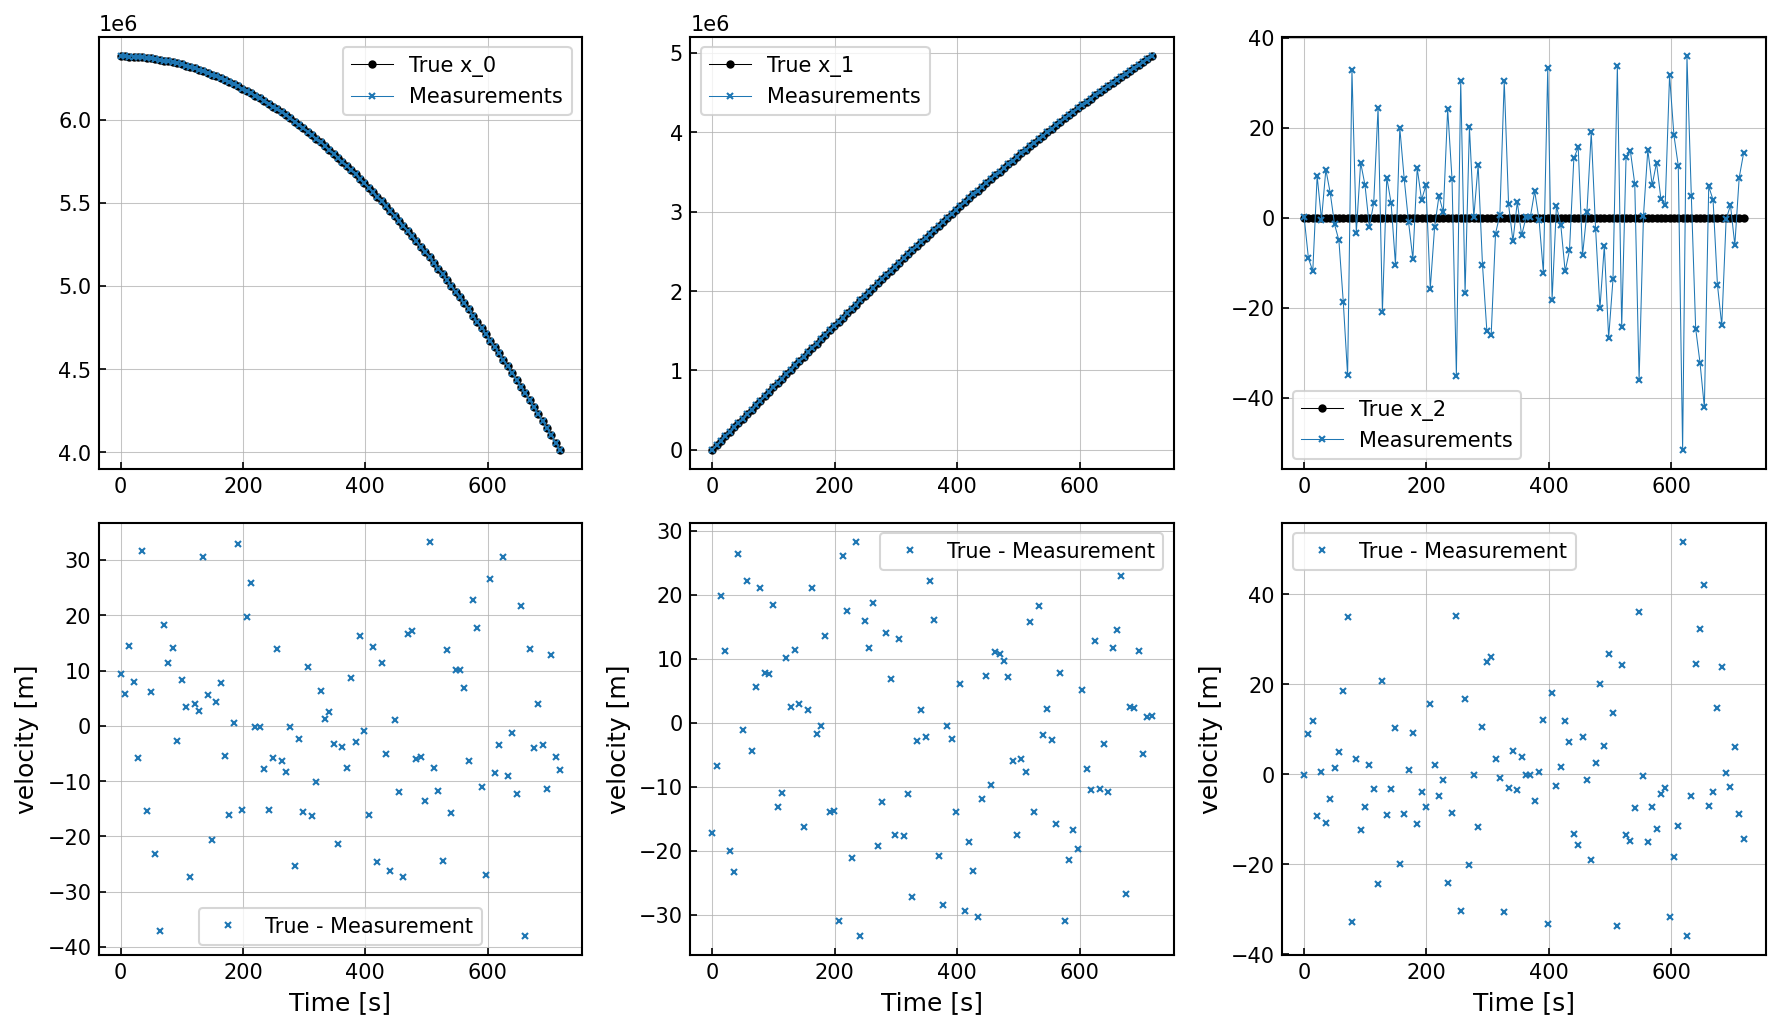

In [286]:
timevec = esys.delta_time_s * np.arange(N_TIME_STEPS+2)
fig, axs = plt.subplots(2,3, figsize=[12,7])
for i, (xi,yi) in enumerate(zip(r_in, r_meas)):
    axs[0,i].plot(timevec, xi, lw=0.5, marker='o', ms=3, color='k', label=f'True x_{i}')
    axs[0,i].plot(timevec, yi, lw=0.5, marker='x', ms=3, color='tab:blue', label='Measurements')
    
    axs[1,i].plot(timevec, xi - yi, lw=0.0, marker='x', ms=3, color='tab:blue', label='True - Measurement')
    
    
# axs[0,0].plot( dt*(0.5*np.arange(kfstates.shape[0]) - 1) , kfstates[:,0], lw=1, marker='x', ms=5, color='tab:orange', label='all states')
# axs[0,0].legend()

# axs[1,1].plot( dt*(0.5*np.arange(kfstates.shape[0]) - 1) , kfstates[:,1], lw=1, marker='x', ms=5, color='tab:orange', label='all states')


axkwargs = {
    # 'xticks': timevec[::10],
    # 'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'velocity [m]',
}
for ax in axs[1]:
    ax.set(**axkwargs)
for ax in axs:
    for ax in ax:
        # ax.grid(True)
        ax.legend()
    
plt.tight_layout()
plt.show()

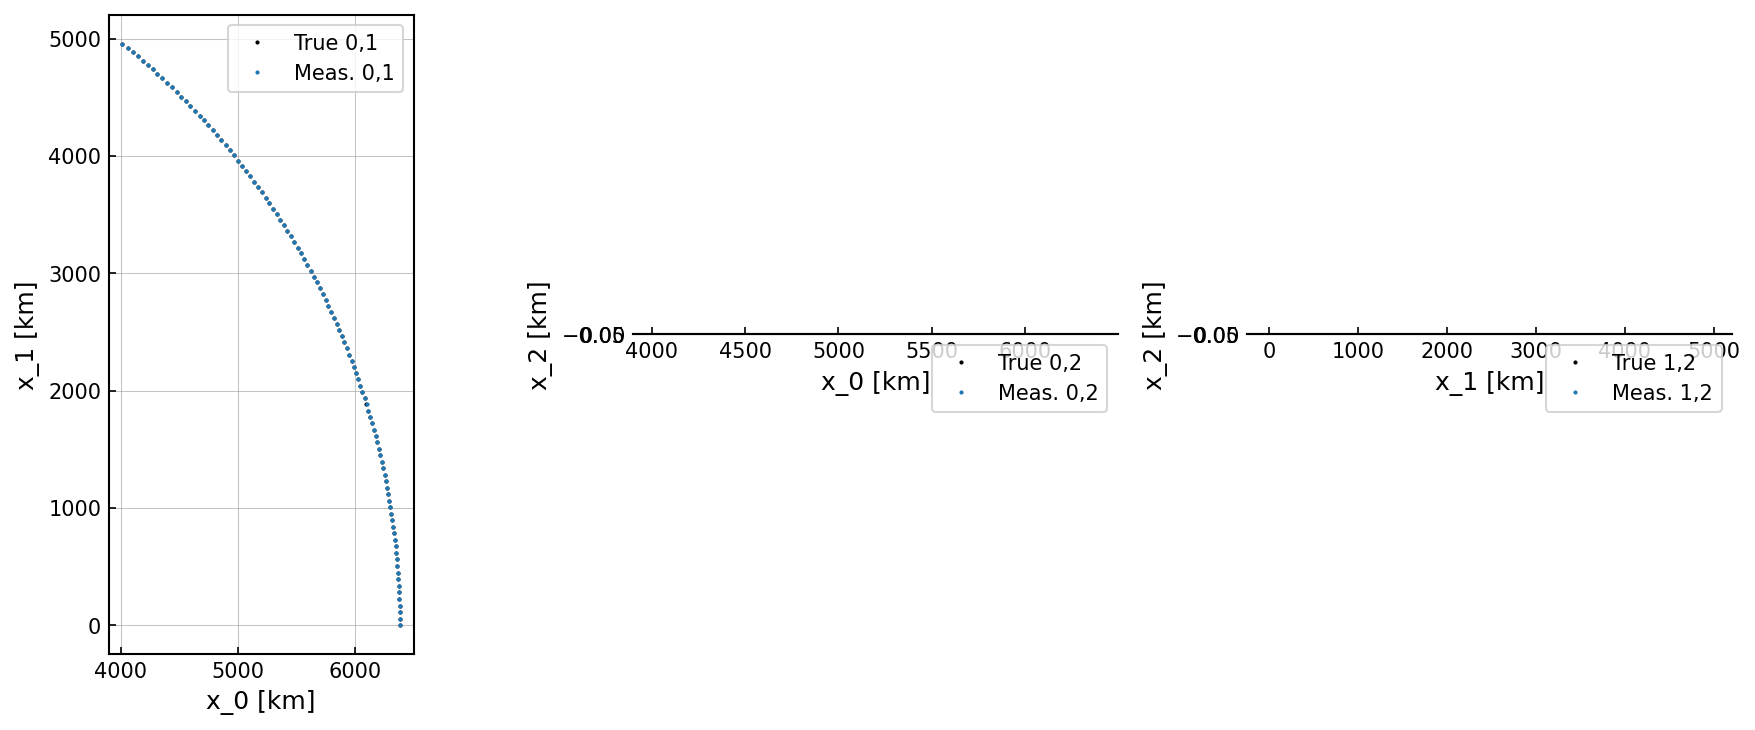

In [287]:
ls = {
    'lw':0,
    'marker':'o',
    'ms': 1,
    'alpha':1,
}
fig = plt.figure(figsize=[12, 5])
gs = gridspec.GridSpec(1, 3, figure=fig)

axs = [fig.add_subplot(gs[0, i]) for i in range(3)]
axcount = 0
dist_scale = 1/const.kilo
for i in range(3):
    for j in range(i+1, 3):
        ax = axs[axcount]
        ax.plot(dist_scale*r_in[i], dist_scale*r_in[j], **ls, color='k', label=f'True {i},{j}')
        ax.plot(dist_scale*r_meas[i], dist_scale*r_meas[j], **ls, color='tab:blue', label=f'Meas. {i},{j}')
        
        axkwargs = {
            # 'xticks': timevec[::10],
            # 'ylim': [-20, 20],
            'xlabel': f'x_{i} [km]',
            'ylabel': f'x_{j} [km]',
            'aspect': 'equal'
        }
        axcount += 1

        ax.set(**axkwargs)
        ax.legend()
    
    
plt.tight_layout()
plt.show()

/tmp/ipykernel_49749/987627304.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


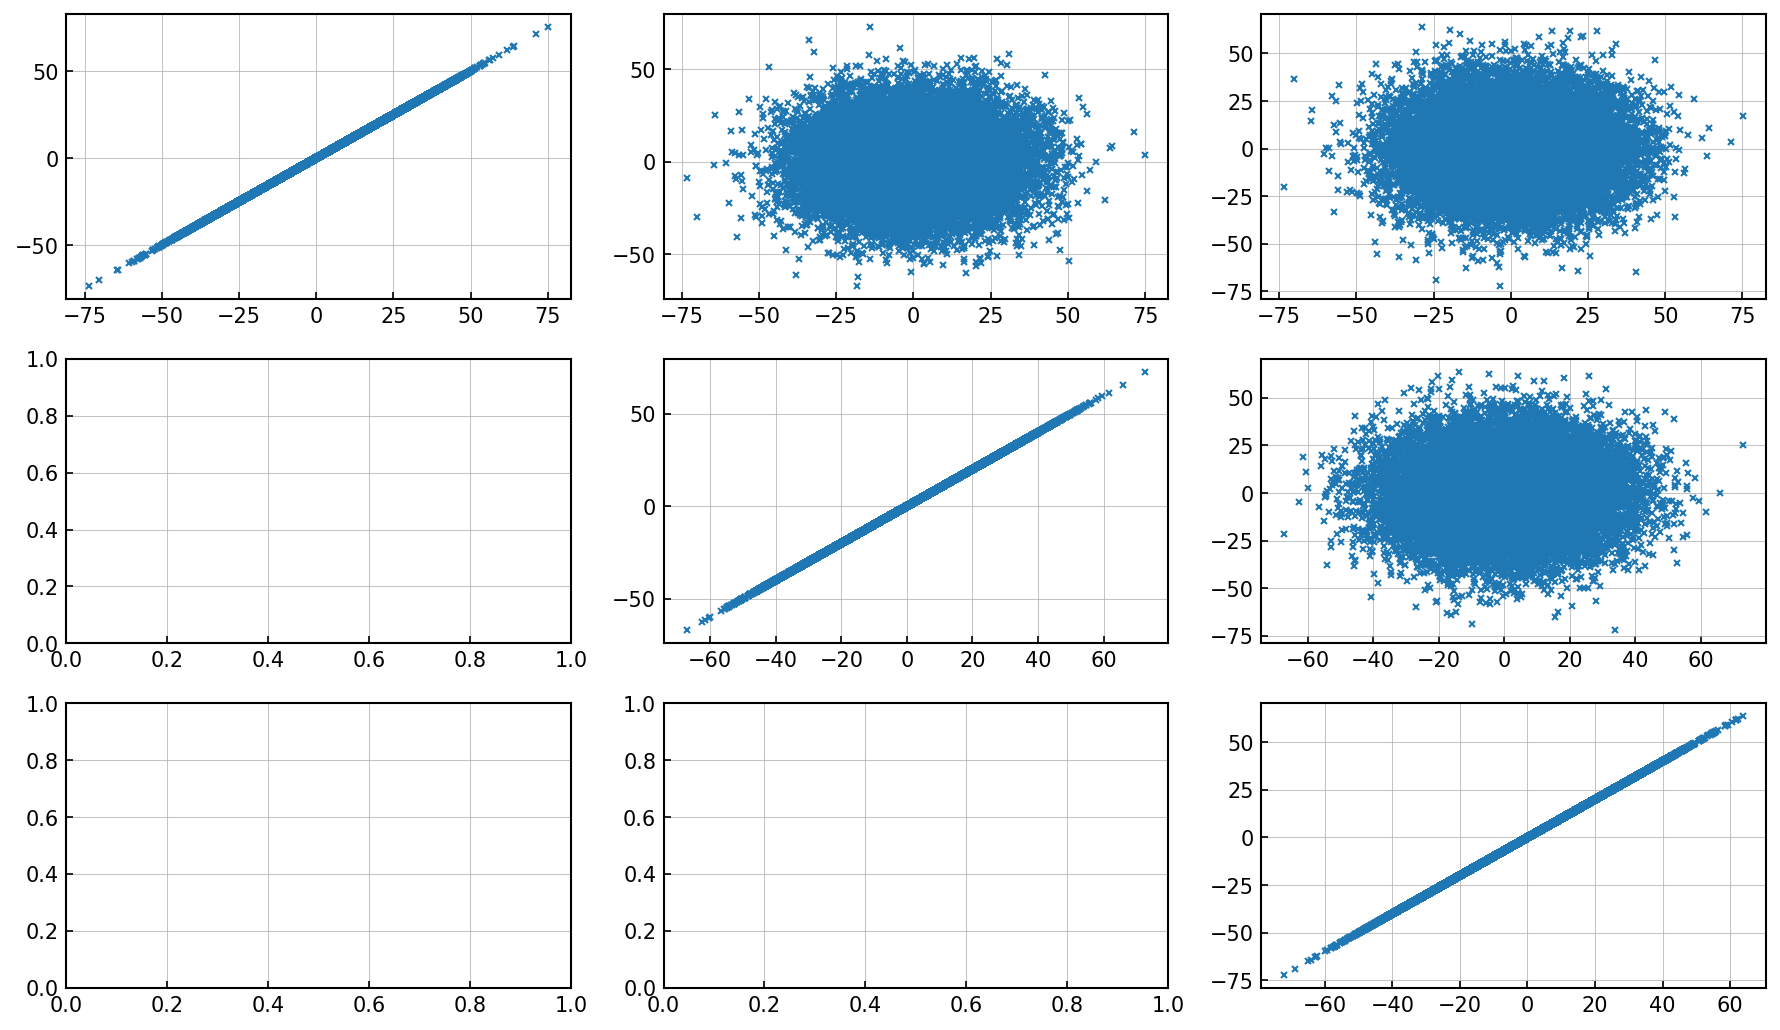

In [135]:
fig, axs = plt.subplots(3,3, figsize=[12,7])

for i in range(3):
    diffi = r_in[i] - r_meas[i]
    for j in range(i, 3):
        diffj = r_in[j] - r_meas[j]
        axs[i,j].plot(diffi, diffj, lw=0.0, marker='x', ms=3, color='tab:blue', label='True - Measurement')


        axkwargs = {
            # 'xticks': timevec[::10],
            # 'ylim': [-20, 20],
            'xlabel': f'x_{i} [km]',
            'ylabel': f'x_{j} [km]',
            'aspect': 'equal'
        }
        axcount += 1

        ax.set(**axkwargs)
        ax.legend()
        
plt.tight_layout()
plt.show()

# State estimation with Kalman Filter

In [288]:
dt = SIM_TIME_DELTA_S * 3
STATE_ORDER = 2 # constant acceleration
nstate = STATE_ORDER + 1
# state: [position, velocity, accel]       
F1 = se.gen_newtonian_motion_update_matrix(dt, state_vec_order=STATE_ORDER)
F2 = se.gen_newtonian_motion_update_matrix(dt, state_vec_order=STATE_ORDER)
F3 = se.gen_newtonian_motion_update_matrix(dt, state_vec_order=STATE_ORDER)
F = np.block([
    [F1, np.zeros(shape=[nstate, nstate + nstate])],
    [np.zeros(shape=[nstate, nstate]), F2, np.zeros(shape=[nstate, nstate]) ],
    [np.zeros(shape=[nstate, nstate + nstate]), F3],
])
print(F)

[[  1.       21.33    227.48445   0.        0.        0.        0.
    0.        0.     ]
 [  0.        1.       21.33      0.        0.        0.        0.
    0.        0.     ]
 [  0.        0.        1.        0.        0.        0.        0.
    0.        0.     ]
 [  0.        0.        0.        1.       21.33    227.48445   0.
    0.        0.     ]
 [  0.        0.        0.        0.        1.       21.33      0.
    0.        0.     ]
 [  0.        0.        0.        0.        0.        1.        0.
    0.        0.     ]
 [  0.        0.        0.        0.        0.        0.        1.
   21.33    227.48445]
 [  0.        0.        0.        0.        0.        0.        0.
    1.       21.33   ]
 [  0.        0.        0.        0.        0.        0.        0.
    0.        1.     ]]


In [147]:
a = np.arange(9)
a.shape
a = np.atleast_2d(a)
a.shape

(1, 9)

In [ ]:
N_DIMS = 3
# measurement process (state to measurement)
H = np.zeros([3,N_DIMS*nstate])
for i in range(N_DIMS):
    H[i,i*nstate] = 1

print(H)

# process noise
Q = 1 * np.eye(N_DIMS*nstate)
# measurement noise
R = np.diag(np.array([0.1, 0.1, 0.1])) * 1e-1

# initial state
x0 = np.array([[5, 0, 0, 1, 0, 0, 1, 0, 0]]).T
# initial uncertainty. make high to convey broader prior
P0 = np.diag([100, 9, 25, 100, 9, 25, 100, 9, 25])      
# controls
B = np.eye(6)
u = np.zeros_like(x0)

# # init Kalman filter
# kf = se.KalmanFilter(x0, P0, F, B, u, Q, H, R )

# for z in measurements:
#     x_est, _ = kf.perform_epoch(u=None, z=z.reshape([-1,1]), postcovkwargs={'stable':True})


# print("True position:", [f"({e[0]:.2f}, {e[1]:.2f})" for e in xtrue])
# print("Measured:", [f"({e[0]:.2f}, {e[1]:.2f})" for e in xmeas])

# estimatesxv = kf.get_states(which='estimates')
# print("Estimates:", [f"{e:.2f}" for e in estimatesxv[:,0]])
# kfstates = kf.get_states(which='all')

# fig, axs = plt.subplots(2,2, figsize=[7,7])
# for i in range(2):
#     axs[0,i].plot(timevec, xtrue[:,i], lw=0.5, marker='o', ms=7, color='k', label='True x')
#     axs[0,i].plot(timevec, xmeas[:,i], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
#     axs[0,i].plot(timevec, estimatesxv[:,(STATE_ORDER+1)*i], lw=1, marker='d', ms=5, color='tab:orange', mfc='none',label='Estimates x')
    
#     axs[1,i].plot(timevec, vtrue[:,i]*np.ones(n_measurements), lw=0.5, marker='o', ms=7, color='k', label='True v')
#     axs[1,i].plot(timevec, vmeas[:,i], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
#     axs[1,i].plot(timevec, estimatesxv[:,(STATE_ORDER+1)*i+1], lw=1, marker='d', ms=5, color='tab:orange',mfc='none', label='Estimates v')

# # axs[0,0].plot( dt*(0.5*np.arange(kfstates.shape[0]) - 1) , kfstates[:,0], lw=1, marker='x', ms=5, color='tab:orange', label='all states')
# axs[0,0].legend()

# # axs[1,1].plot( dt*(0.5*np.arange(kfstates.shape[0]) - 1) , kfstates[:,1], lw=1, marker='x', ms=5, color='tab:orange', label='all states')

# axs[1,1].legend()

# axkwargs = {
#     # 'xticks': timevec[::10],
#     # 'ylim': [-20, 20],
#     'xlabel': 'Time [s]',
#     'ylabel': 'velocity [m]',
# }
# for ax in axs[1]:
#     ax.set(**axkwargs)
# for ax in axs:
#     for ax in ax:
#         ax.grid(True)
    
# plt.tight_layout()
# plt.show()

[[1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]]


In [133]:
def transform_xyz_to_orbitalpolar(xyz, dt):
    r0_vec = xyz[:,:-1]
    r1_vec = xyz[:,1:]

    v0_vec = (r1_vec - r0_vec) / dt

    rhat = r0_vec / LA.norm(r0_vec, axis=0, ord=2)
    thhat = v0_vec / LA.norm(v0_vec, axis=0, ord=2)
    khat = LA.cross(rhat, thhat, axis=0)
    zhat = np.array([[0,0,1]]).T
    rot_angle = np.arccos(khat.T @ zhat)

    return rhat, v0_vec, thhat, khat, rot_angle



rhat, v0_vec, thhat, khat, rot_angle = transform_xyz_to_orbitalpolar(r_meas, 1)

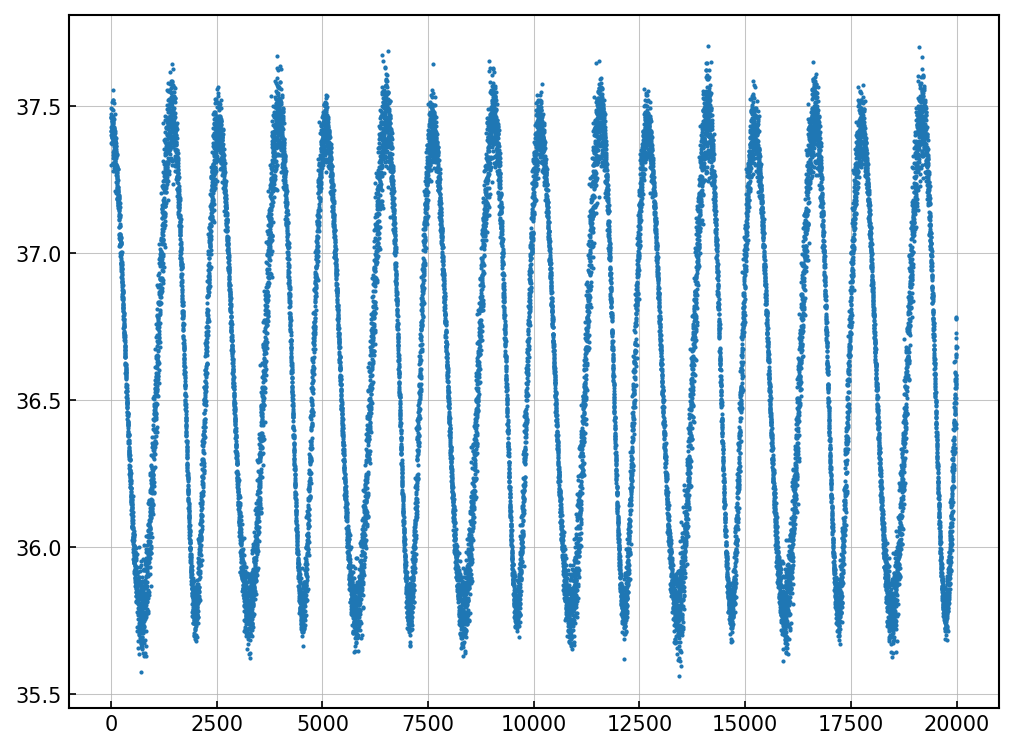

In [134]:
fig, ax = plt.subplots()
ax.plot((180/const.pi)*rot_angle.squeeze(), lw=0, marker='o', ms=1)
plt.show()

In [114]:
rhat

array([[ 1.00000000e+00,  9.99996926e-01,  9.99987731e-01, ...,
         2.36884544e-01,  2.39291885e-01,  2.41697083e-01],
       [ 2.69104518e-06,  2.47937920e-03,  4.95354790e-03, ...,
        -9.71537808e-01, -9.70947678e-01, -9.70351751e-01],
       [ 3.21361195e-08, -1.41598600e-06, -1.85086257e-06, ...,
         1.87137222e-07,  4.25271918e-06, -7.47777979e-07]],
      shape=(3, 2001))

In [115]:
r_meas[:,0] - r_meas[:,1]

array([ 1.59799899e+01, -1.57991189e+04,  9.23776099e+00])

In [103]:
ZHAT @ XHAT

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 3)

# dev

In [87]:
from scipy.stats import norm
from scipy.stats import qmc

sampler = qmc.Sobol(d=6, scramble=True)  # 6D phase space x,y,z,px,py,pz
samples = sampler.random(n=256)          # uniform in [0,1]^6
gaussian_samples = norm.ppf(samples)      # map to Gaussian

In [88]:
gaussian_samples

array([[-0.86375246, -0.72618312,  1.58653921, -1.06827507, -0.38961394,
        -0.90190022],
       [ 1.06666674,  0.43866115, -0.89282639,  0.22105318,  0.92626108,
         1.09423752],
       [ 0.38385717, -0.10475997,  0.2704485 , -0.45031152,  0.57077274,
         0.10449898],
       ...,
       [ 0.39297277,  0.23230158, -0.97012623,  2.07077197, -0.8888465 ,
        -1.37019006],
       [ 1.04721372, -0.55942305,  0.30497761, -0.6873056 , -0.55606949,
        -0.63196087],
       [-0.87284826,  1.02741496, -0.6667281 ,  0.11858433,  0.69410375,
         0.50597121]], shape=(256, 6))

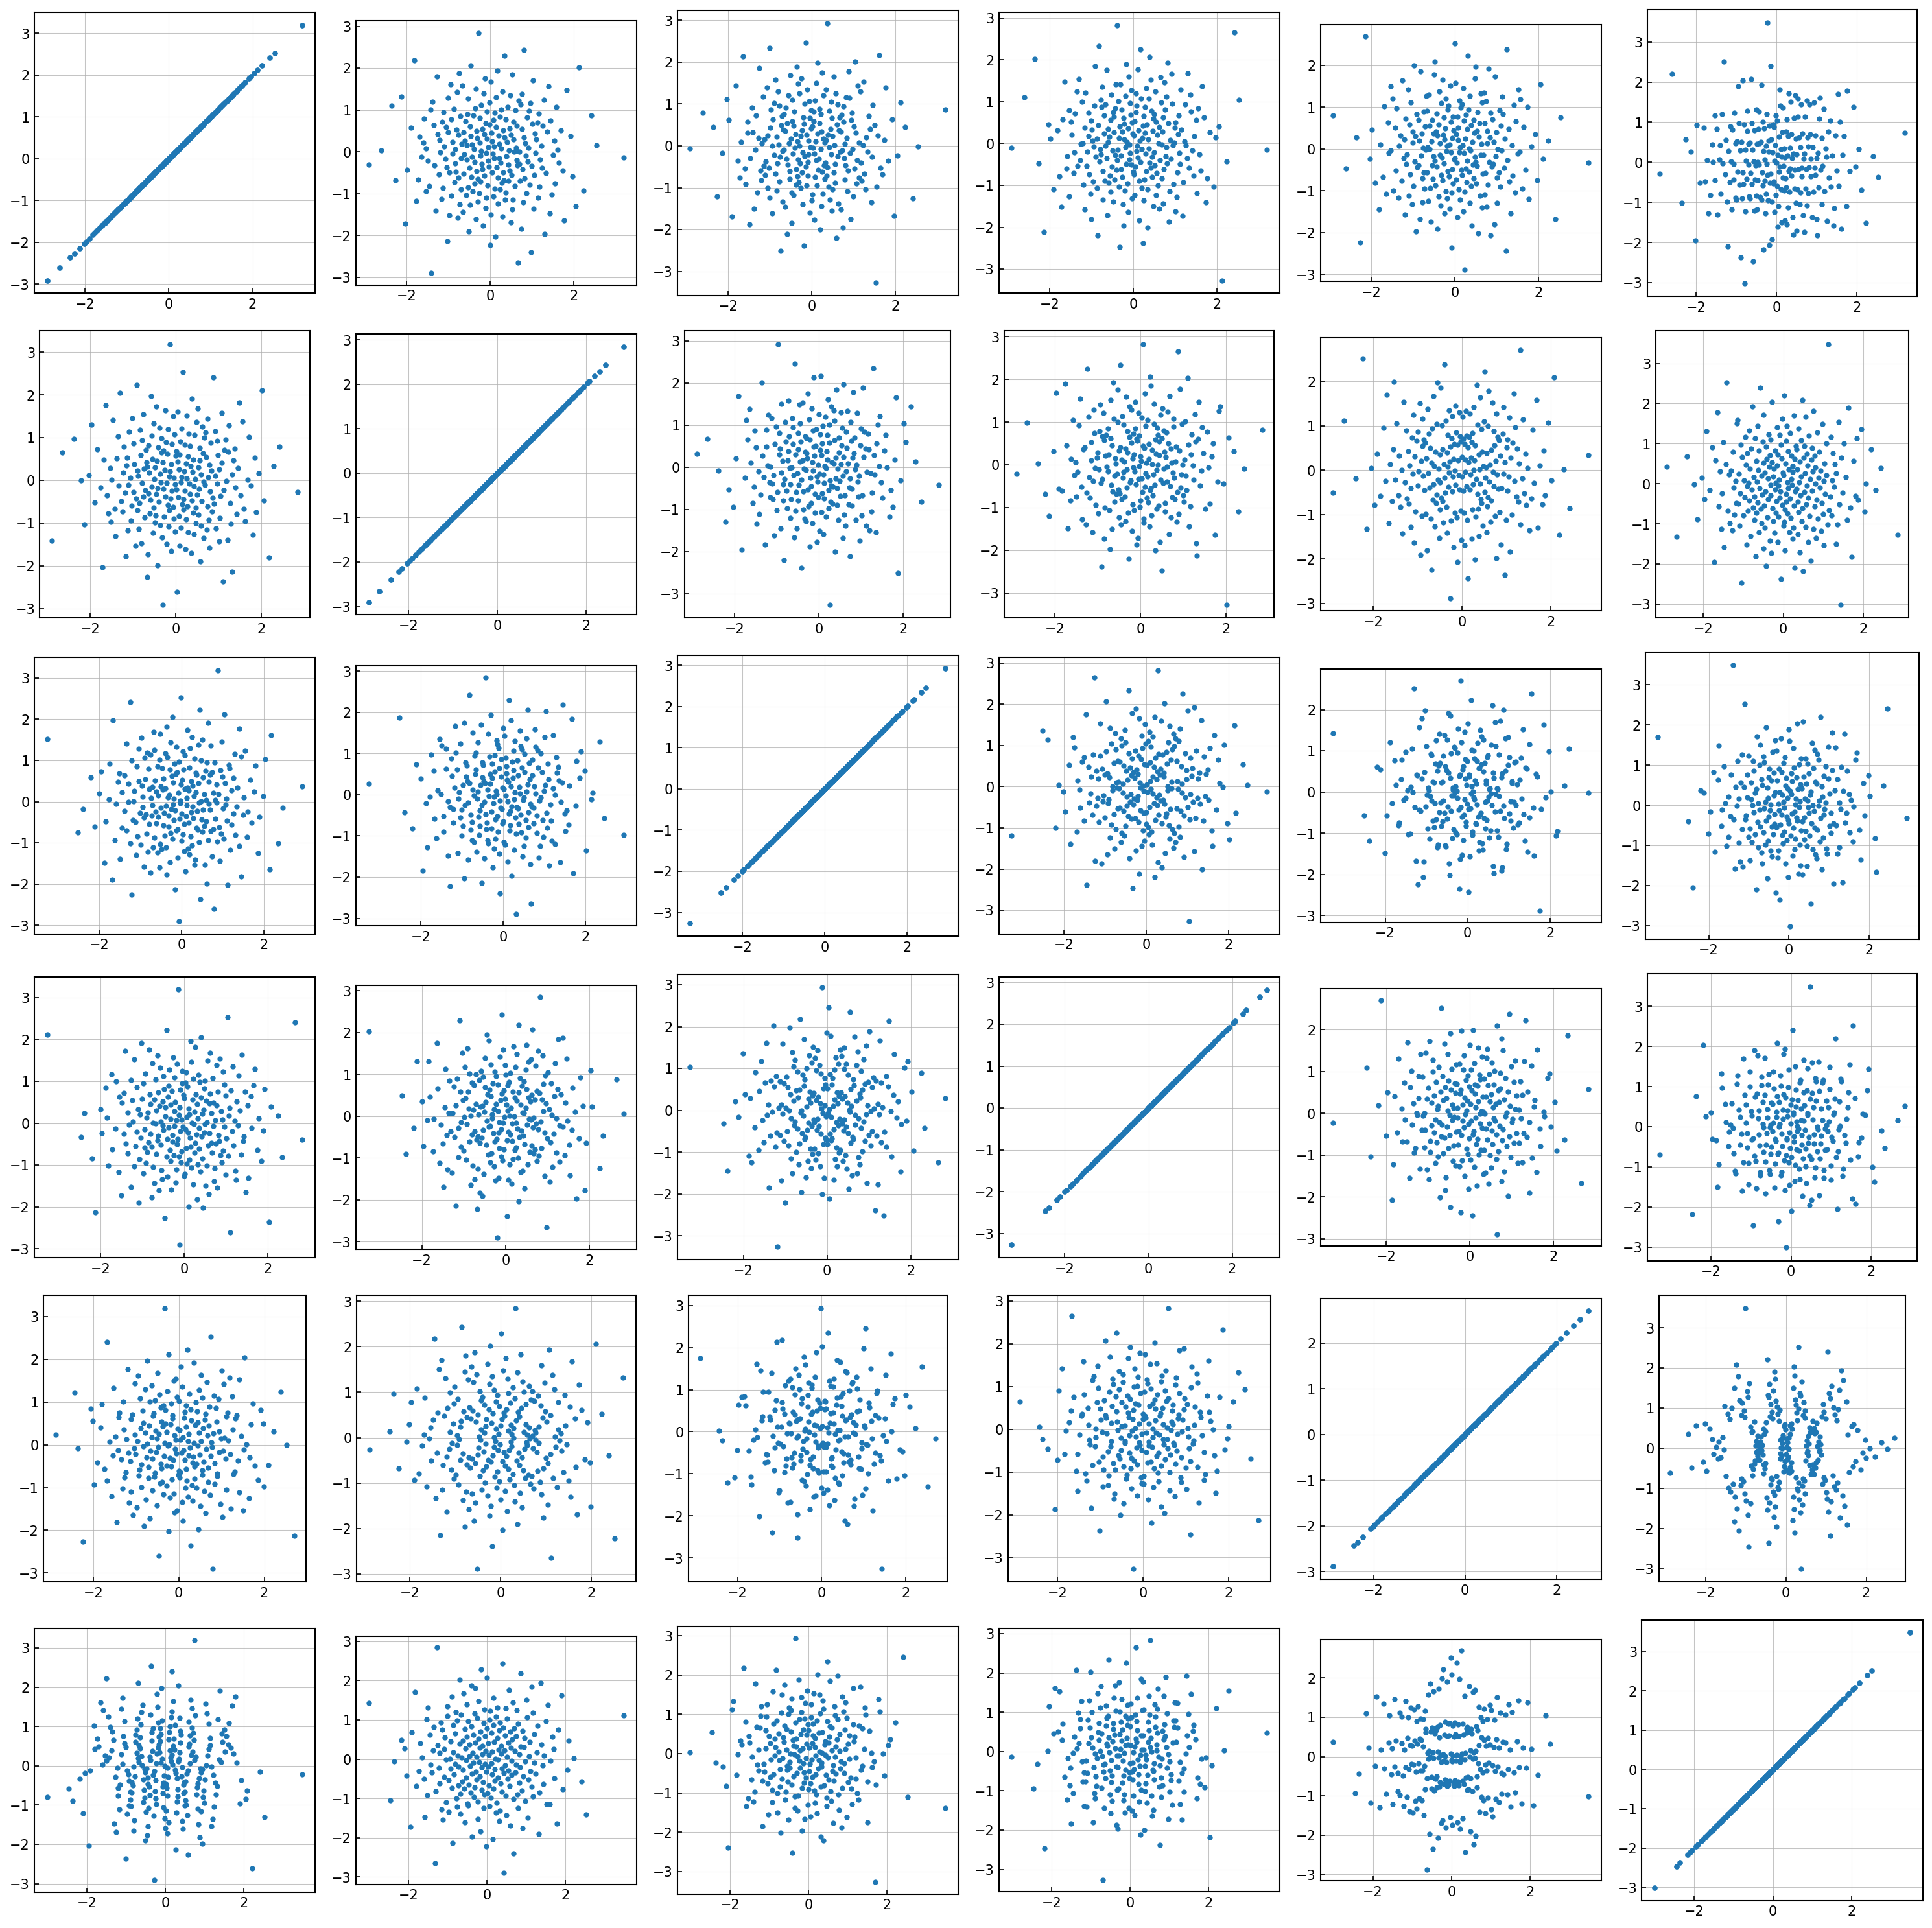

In [92]:
fig, axs = plt.subplots(6,6, figsize=[20,20])

for i in range(6):
    gsi = gaussian_samples[:,i]
    for j in range(i, 6):
        gsj = gaussian_samples[:,j]
        axs[i,j].plot(gsi, gsj, lw=0.0, marker='o', ms=3, color='tab:blue')
        axs[j,i].plot(gsj, gsi, lw=0.0, marker='o', ms=3, color='tab:blue')

 
        axkwargs = {
            # 'xticks': timevec[::10],
            # 'ylim': [-20, 20],
            # 'xlabel': 'Time [s]',
            # 'ylabel': 'velocity [m]',
            'aspect': 'equal',
        }

        axs[i,j].set(**axkwargs)
        axs[j,i].set(**axkwargs)
    
plt.tight_layout()
plt.show()

In [93]:
gaussian_samples.mean(axis=0)

array([ 0.0008431 , -0.00171777, -0.00153749, -0.00111727, -0.00036712,
        0.00198325])

In [94]:
gaussian_samples.std(axis=0)

array([1.00410977, 0.99778466, 1.00271895, 1.00248244, 0.99556134,
       1.00634257])